<a href="https://colab.research.google.com/github/Kaweri05/Time-series-using-ML/blob/main/Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd


In [ ]:
df=pd.read_csv("/content/Electric_Production.csv")

In [ ]:
df.head()

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151


In [ ]:
df.isnull()

,DATE,IPG2211A2N
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
392,False,False
393,False,False
394,False,False
395,False,False


In [ ]:
df.isnull().sum()

,0
DATE,0
IPG2211A2N,0


In [12]:
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day

display(df.head())

,Production,year,month,day
DATE,,,,
1985-01-01,72.5052,1985,1,1
1985-02-01,70.6720,1985,2,1
1985-03-01,62.4502,1985,3,1
1985-04-01,57.4714,1985,4,1
1985-05-01,55.3151,1985,5,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DATE        397 non-null    object 
 1   IPG2211A2N  397 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.3+ KB


In [8]:
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.set_index('DATE')
df.rename(columns={'IPG2211A2N': 'Production'}, inplace=True)

In [9]:
display(df.head())

,Production
DATE,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


Now that the 'DATE' column is properly formatted and set as the index, and the column is renamed, we can start with some basic time series analysis. Let's visualize the electricity production over time.

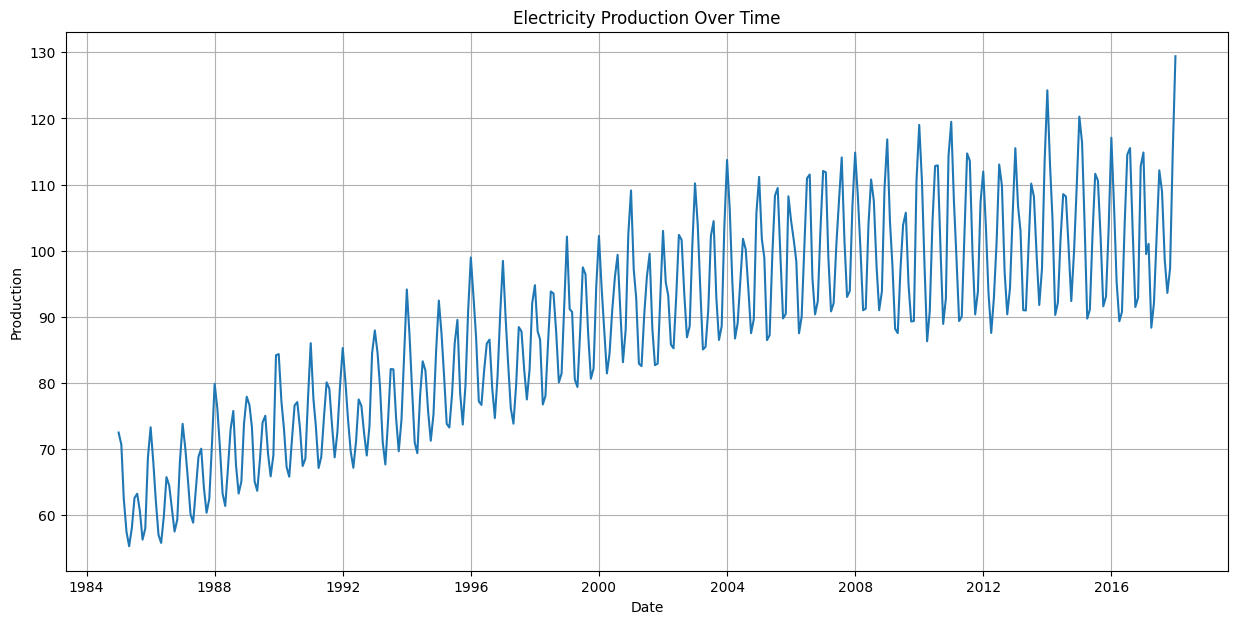

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))
sns.lineplot(data=df, x=df.index, y='Production')
plt.title('Electricity Production Over Time')
plt.xlabel('Date')
plt.ylabel('Production')
plt.grid(True)
plt.show()

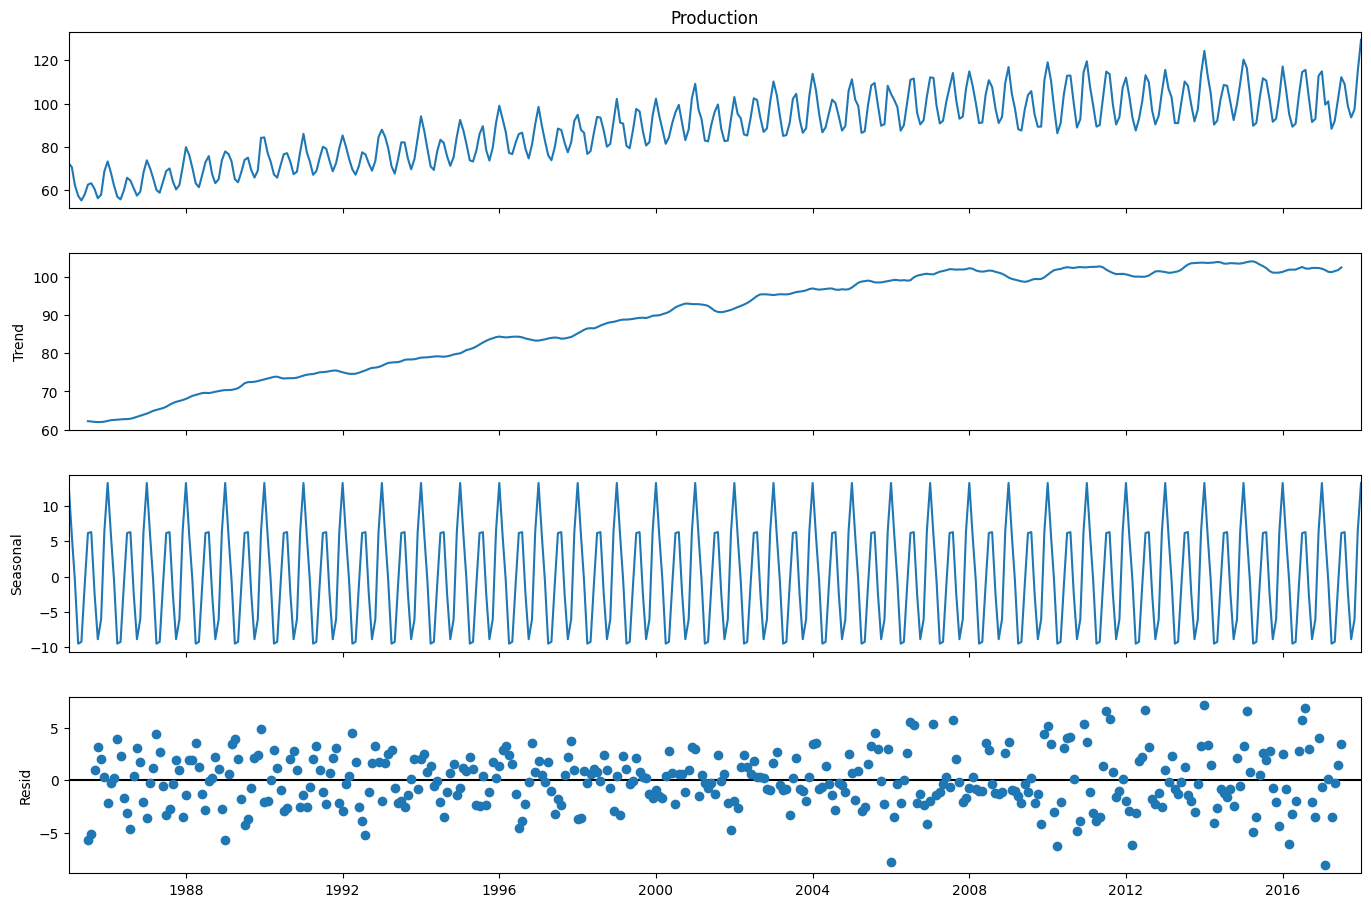

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Assuming 'Production' is the column with time series data
# and the DataFrame 'df' is already indexed by 'DATE'

decomposition = seasonal_decompose(df['Production'], model='additive')
fig = decomposition.plot()
fig.set_size_inches(15, 10)
plt.show()

The time series decomposition helps us visualize the trend, seasonality, and residuals. This information is crucial for selecting appropriate forecasting models. Next, we can move on to applying a forecasting model, such as ARIMA or SARIMA, considering the seasonal patterns observed.

### Linear Regression Model for Forecasting

Now that we have processed the date information into `year`, `month`, and `day` features, we can use these to build a simple linear regression model to predict electricity production. While linear regression might not capture all the complexities of time series data (like seasonality and trend over time), it's a good starting point to understand the relationship between these features and production.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = df[['year', 'month', 'day']]
y = df['Production']

# Split data into training and testing sets
# We'll use a time-based split rather than random for time series data
# For simplicity, let's take the last 20% of data as test set
test_size = 0.2
split_index = int(len(df) * (1 - test_size))

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training data size: {len(X_train)}")
print(f"Testing data size: {len(X_test)}")

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Training data size: 317
Testing data size: 80

Mean Squared Error: 184.76
R-squared: -1.02


### Visualize Predictions

Let's visualize the actual vs. predicted values to see how well our linear regression model performed.

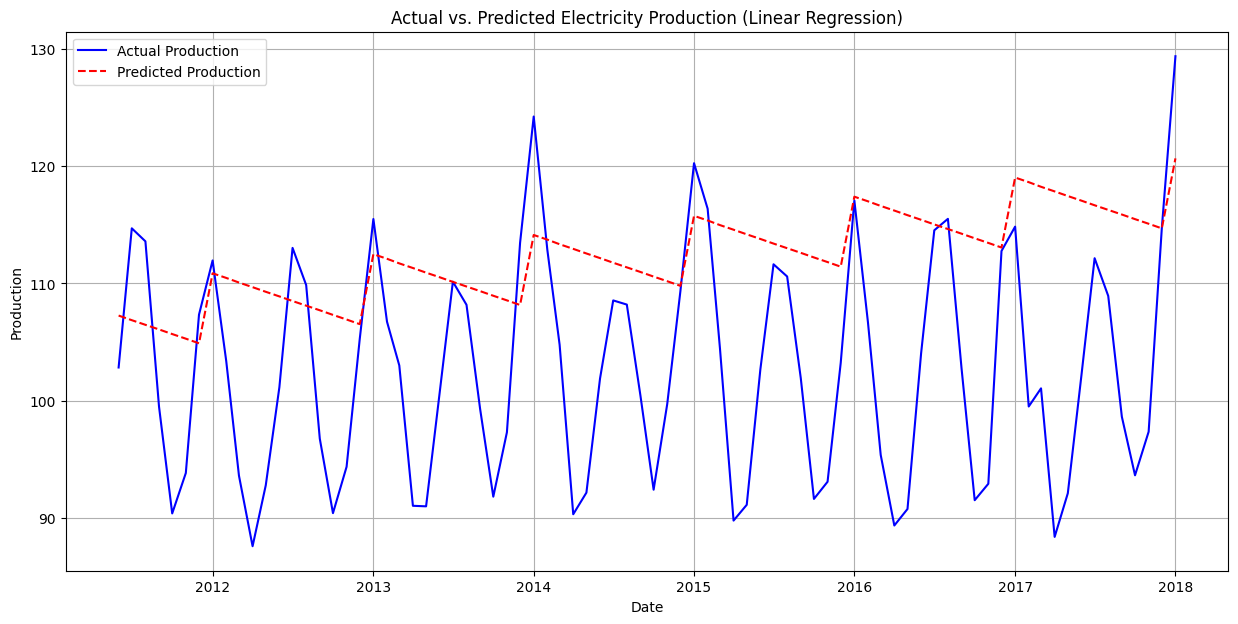

In [14]:
plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test, label='Actual Production', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted Production', color='red', linestyle='--')
plt.title('Actual vs. Predicted Electricity Production (Linear Regression)')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.grid(True)
plt.show()

### Forecasting with Prophet and Dashboard Visualization

Given the limitations of simple linear regression for time series data with strong seasonality and trend, we'll now use Facebook's Prophet library. Prophet is designed for business forecasting and can effectively capture these patterns. After generating forecasts, we will create interactive visualizations for a dashboard-like experience using Plotly.

In [15]:
# Install Prophet if you haven't already
# !pip install prophet

from prophet import Prophet
import plotly.graph_objects as go
import plotly.express as px

# Prepare data for Prophet: Prophet requires columns named 'ds' (datestamp) and 'y' (target)
prophet_df = df.reset_index()[['DATE', 'Production']].rename(columns={'DATE': 'ds', 'Production': 'y'})

# Initialize and fit the Prophet model
# We'll enable yearly seasonality as observed in the decomposition
model_prophet = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)
model_prophet.fit(prophet_df)

# Create a future DataFrame for predictions (e.g., next 24 months)
future = model_prophet.make_future_dataframe(periods=24, freq='MS')

# Make predictions
forecast = model_prophet.predict(future)

display(forecast.head())

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1985-01-01,61.420349,70.834227,77.995064,61.420349,61.420349,13.017911,13.017911,13.017911,13.017911,13.017911,13.017911,0.0,0.0,0.0,74.438259
1,1985-02-01,61.602769,62.614784,70.017056,61.602769,61.602769,4.613379,4.613379,4.613379,4.613379,4.613379,4.613379,0.0,0.0,0.0,66.216148
2,1985-03-01,61.767536,57.222301,64.345921,61.767536,61.767536,-0.932514,-0.932514,-0.932514,-0.932514,-0.932514,-0.932514,0.0,0.0,0.0,60.835023
3,1985-04-01,61.949957,48.766188,55.630702,61.949957,61.949957,-9.538511,-9.538511,-9.538511,-9.538511,-9.538511,-9.538511,0.0,0.0,0.0,52.411446
4,1985-05-01,62.126493,49.148033,56.772340,62.126493,62.126493,-9.311998,-9.311998,-9.311998,-9.311998,-9.311998,-9.311998,0.0,0.0,0.0,52.814495


### Predicted Demand Visualization (Prophet)

Now, let's visualize the actual electricity production along with Prophet's forecast and uncertainty intervals. This plot will serve as a key component of our demand prediction dashboard.

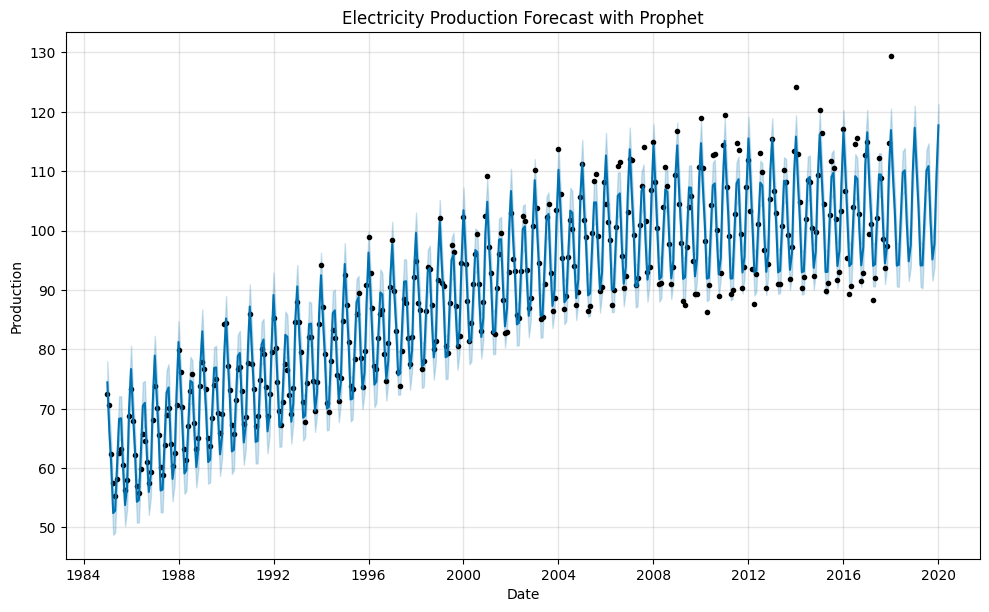

In [16]:
# Plot the Prophet forecast
fig = model_prophet.plot(forecast)
plt.title('Electricity Production Forecast with Prophet')
plt.xlabel('Date')
plt.ylabel('Production')
plt.show()

# For an interactive plot using Plotly
fig_interactive = go.Figure()
fig_interactive.add_trace(go.Scatter(x=prophet_df['ds'], y=prophet_df['y'], mode='lines', name='Actual Production'))
fig_interactive.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat'], mode='lines', name='Prophet Forecast', line=dict(color='red')))
fig_interactive.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat_lower'], fill='tonexty', mode='lines', line=dict(color='rgba(255,0,0,0)'), name='Lower Bound', showlegend=False))
fig_interactive.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat_upper'], fill='tonexty', mode='lines', line=dict(color='rgba(255,0,0,0)'), name='Upper Bound', showlegend=False))

fig_interactive.update_layout(title='Interactive Electricity Production Forecast (Prophet)',
                              xaxis_title='Date',
                              yaxis_title='Production',
                              hovermode='x unified')
fig_interactive.show()

### Demand Distribution Visualizations

To understand the distribution of electricity demand, we can visualize it across different temporal features like month and year. These plots will help us identify consistent patterns and variations.

In [17]:
# Demand distribution by month (Box plot)
fig_month = px.box(df.reset_index(), x='month', y='Production',
                   title='Electricity Production Distribution by Month',
                   labels={'month': 'Month', 'Production': 'Production'})
fig_month.update_xaxes(tickvals=list(range(1, 13)), ticktext=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
fig_month.show()

# Demand distribution by year (Line plot with smoother)
fig_year = px.line(df.reset_index(), x='year', y='Production', title='Electricity Production Over Years',
                   labels={'year': 'Year', 'Production': 'Production'}, markers=True)
fig_year.update_traces(mode='lines+markers')
fig_year.show()

This set of visualizations provides a basic dashboard to predict future demand using Prophet and analyze demand distribution by month and year. You can interact with these Plotly graphs to explore the data further.

### Clustering for Hidden Demand Patterns (K-Means and DBSCAN)

We will now use clustering algorithms (K-Means and DBSCAN) to identify hidden patterns in electricity demand. Before applying the algorithms, we need to scale the data to ensure that all features contribute equally to the distance calculations.

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a DataFrame for clustering features. We'll use 'Production', 'month', 'year', and 'day'.
# Note: 'year' might show a trend, 'month' and 'day' seasonality.
# We might need to consider cyclical features for month/day if distance metrics are sensitive.
# For now, let's use them directly.

df_clustering = df[['Production', 'year', 'month', 'day']].copy()

# Scale the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

# Convert back to DataFrame for easier handling, keeping original index
df_scaled = pd.DataFrame(df_scaled, columns=df_clustering.columns, index=df_clustering.index)

display(df_scaled.head())

,Production,year,month,day
DATE,,,,
1985-01-01,-1.063349,-1.680227,-1.586184,0.0
1985-02-01,-1.182632,-1.680227,-1.297059,0.0
1985-03-01,-1.717612,-1.680227,-1.007933,0.0
1985-04-01,-2.041574,-1.680227,-0.718808,0.0
1985-05-01,-2.181881,-1.680227,-0.429683,0.0


#### K-Means Clustering

First, we'll apply K-Means clustering. A common way to determine the optimal number of clusters (`k`) is the Elbow Method, which looks for a bend in the plot of the sum of squared distances to the nearest cluster center.

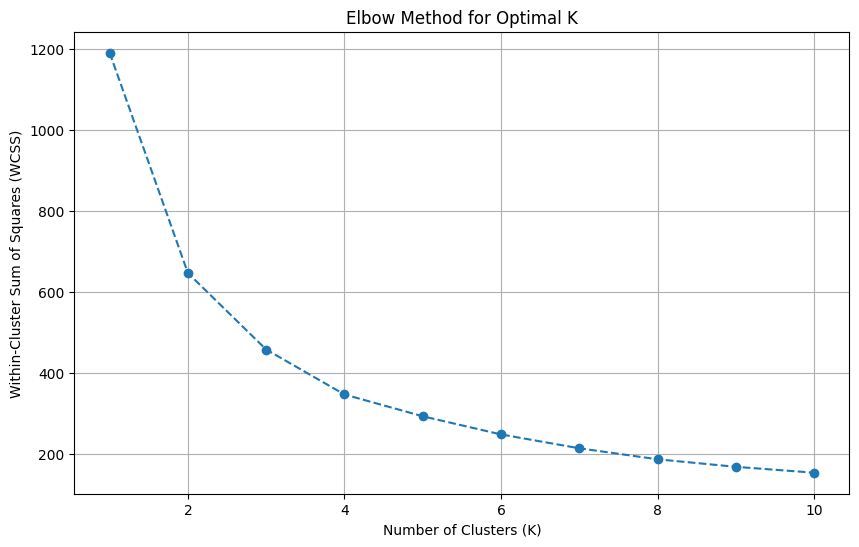

In [19]:
# Elbow Method to find optimal k
wcss = [] # Within-cluster sum of squares
max_k = 10 # Maximum number of clusters to check

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10) # Set n_init to suppress warning
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

Based on the elbow plot, you can choose an appropriate `k`. For demonstration purposes, let's choose `k=3` (or adjust based on the plot's elbow point).

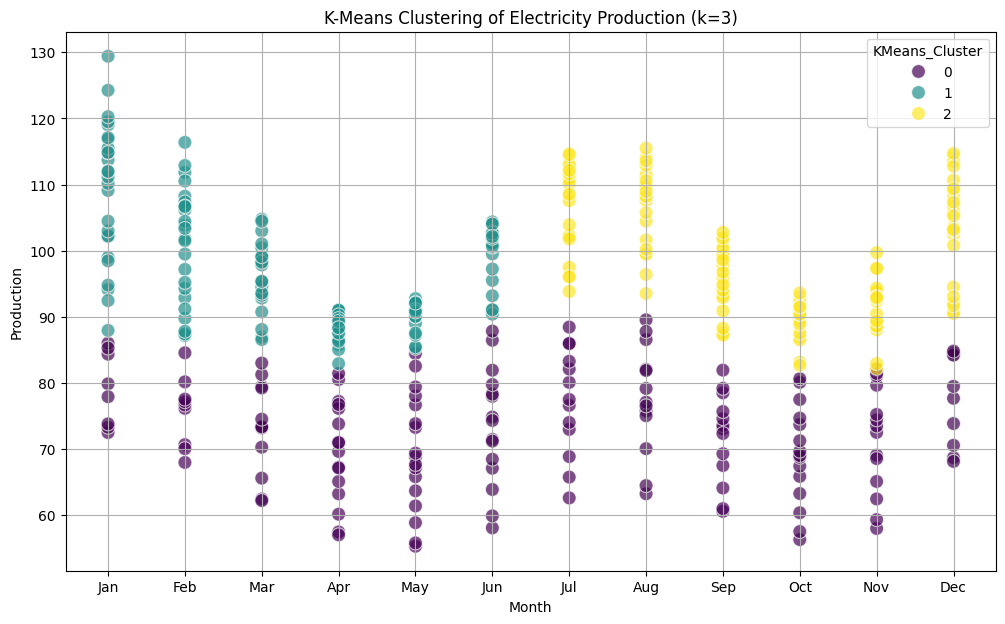

,Production,year,month,day,KMeans_Cluster
DATE,,,,,
1985-01-01,72.5052,1985,1,1,0
1985-02-01,70.6720,1985,2,1,0
1985-03-01,62.4502,1985,3,1,0
1985-04-01,57.4714,1985,4,1,0
1985-05-01,55.3151,1985,5,1,0


In [20]:
# Apply K-Means with the chosen number of clusters (e.g., k=3)
k_optimal = 3 # Adjust based on the elbow plot
kmeans_model = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_clustering['KMeans_Cluster'] = kmeans_model.fit_predict(df_scaled)

# Visualize K-Means clusters (e.g., Production vs. Month, colored by cluster)
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_clustering, x='month', y='Production', hue='KMeans_Cluster', palette='viridis', s=100, alpha=0.7)
plt.title(f'K-Means Clustering of Electricity Production (k={k_optimal})')
plt.xlabel('Month')
plt.ylabel('Production')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.show()

display(df_clustering.head())

#### DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is another clustering algorithm that can find arbitrarily shaped clusters and is robust to outliers. It requires two main parameters: `eps` (the maximum distance between two samples for one to be considered as in the neighborhood of the other) and `min_samples` (the number of samples in a neighborhood for a point to be considered as a core point).

Number of DBSCAN clusters found: 1


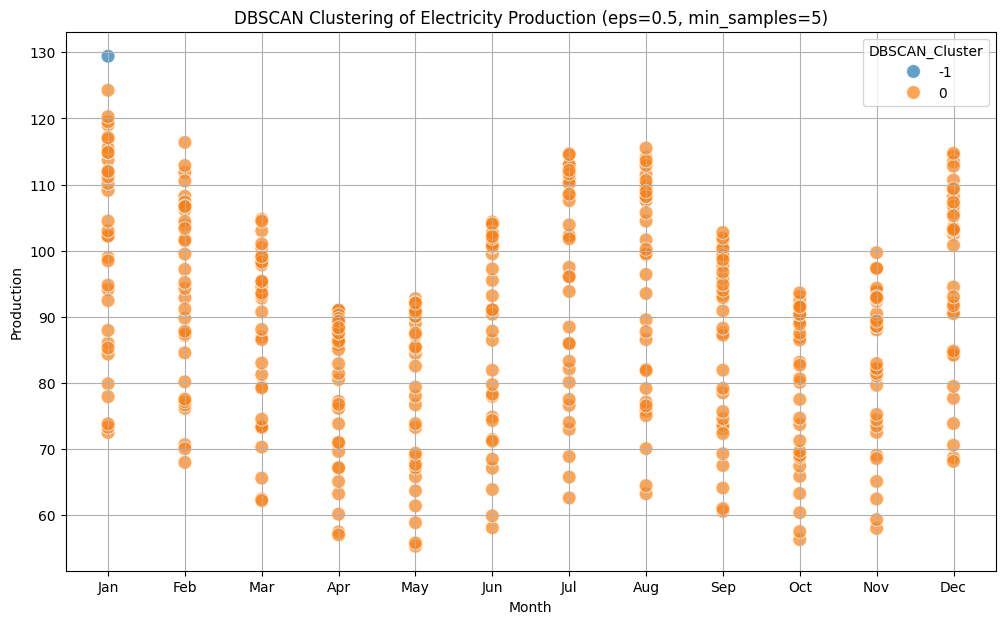

,Production,year,month,day,KMeans_Cluster,DBSCAN_Cluster
DATE,,,,,,
1985-01-01,72.5052,1985,1,1,0,0
1985-02-01,70.6720,1985,2,1,0,0
1985-03-01,62.4502,1985,3,1,0,0
1985-04-01,57.4714,1985,4,1,0,0
1985-05-01,55.3151,1985,5,1,0,0


In [21]:
# Apply DBSCAN clustering
# Choosing appropriate eps and min_samples can be tricky and often requires experimentation.
# Let's start with some arbitrary values for demonstration.
eps_value = 0.5 # A small value, adjust based on feature scaling and data density
min_samples_value = 5 # Minimum number of samples in a neighborhood

dbscan_model = DBSCAN(eps=eps_value, min_samples=min_samples_value)
df_clustering['DBSCAN_Cluster'] = dbscan_model.fit_predict(df_scaled)

# Number of clusters found (excluding noise if any, labeled as -1)
num_dbscan_clusters = len(np.unique(df_clustering['DBSCAN_Cluster'][df_clustering['DBSCAN_Cluster'] != -1]))
print(f"Number of DBSCAN clusters found: {num_dbscan_clusters}")

# Visualize DBSCAN clusters
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_clustering, x='month', y='Production', hue='DBSCAN_Cluster', palette='tab10', s=100, alpha=0.7)
plt.title(f'DBSCAN Clustering of Electricity Production (eps={eps_value}, min_samples={min_samples_value})')
plt.xlabel('Month')
plt.ylabel('Production')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.show()

display(df_clustering.head())

#### Iterative DBSCAN Parameter Tuning

Since the initial DBSCAN run resulted in only one cluster, it suggests that our `eps` and `min_samples` values might be too large or not optimal for identifying distinct, dense clusters in the data. Let's try to iteratively adjust these parameters and observe the number of clusters found. A common approach for selecting `eps` is to use a k-distance graph (usually k=min_samples - 1).

However, for simplicity and to demonstrate the iterative process, we'll try a few different combinations and visualize the results. We will focus on varying `eps` as it's often the most sensitive parameter.

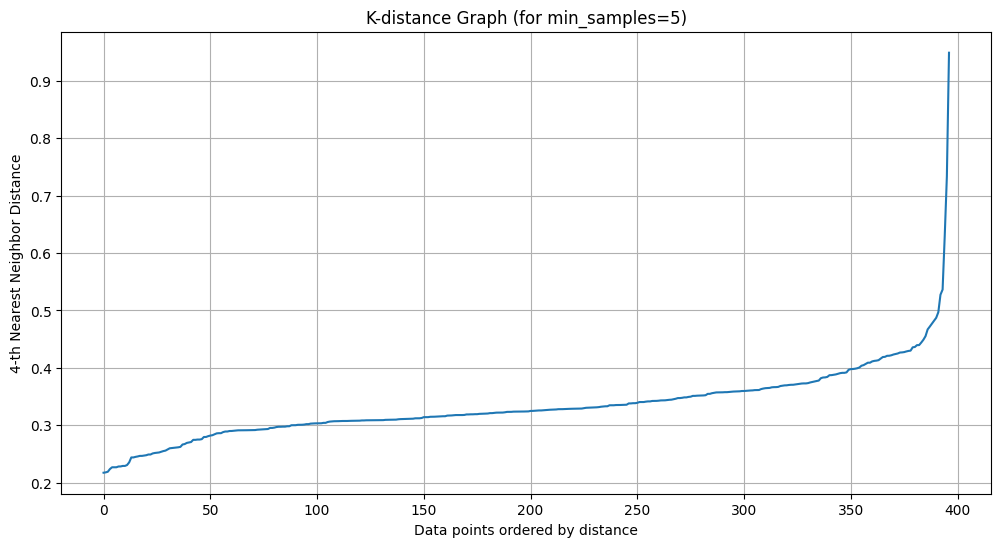

Look for the 'elbow' in the k-distance graph to determine a better eps value.


In [22]:
from sklearn.neighbors import NearestNeighbors

# Calculate k-distance for choosing eps (e.g., k = min_samples - 1, here min_samples = 5, so k=4)
neighbors = NearestNeighbors(n_neighbors=5) # n_neighbors = min_samples
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

distances = np.sort(distances[:, 4], axis=0) # Sort distances to the 4th nearest neighbor

plt.figure(figsize=(12, 6))
plt.plot(distances)
plt.title('K-distance Graph (for min_samples=5)')
plt.xlabel('Data points ordered by distance')
plt.ylabel('4-th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

print("Look for the 'elbow' in the k-distance graph to determine a better eps value.")

Based on the k-distance graph, we can try to pick a more appropriate `eps` value. Let's try a few different `eps` values around the elbow point, and keep `min_samples` consistent for now. We will also try to vary `min_samples` to see its effect.

In [23]:
# Experiment with different DBSCAN parameters
eps_values_to_try = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
min_samples_values_to_try = [3, 5, 7, 10]

results = []

for eps in eps_values_to_try:
    for min_samples in min_samples_values_to_try:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan.fit_predict(df_scaled)
        n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
        n_noise = list(clusters).count(-1)
        results.append({'eps': eps, 'min_samples': min_samples, 'n_clusters': n_clusters, 'n_noise': n_noise})

results_df = pd.DataFrame(results)
display(results_df)

print("From the table above, we can choose parameters that yield a reasonable number of clusters with acceptable noise.")
print("Let's visualize one combination that seems promising.")

,eps,min_samples,n_clusters,n_noise
0,0.1,3,0,397
1,0.1,5,0,397
2,0.1,7,0,397
3,0.1,10,0,397
4,0.2,3,45,203
5,0.2,5,0,397
6,0.2,7,0,397
7,0.2,10,0,397
8,0.3,3,26,32
9,0.3,5,26,182


From the table above, we can choose parameters that yield a reasonable number of clusters with acceptable noise.
Let's visualize one combination that seems promising.


Based on the `results_df`, choose a combination of `eps` and `min_samples` that gives a desirable number of clusters without too much noise. For example, if `eps=0.2` and `min_samples=5` gives a good result, let's visualize it.

Number of REFINED DBSCAN clusters found: 2


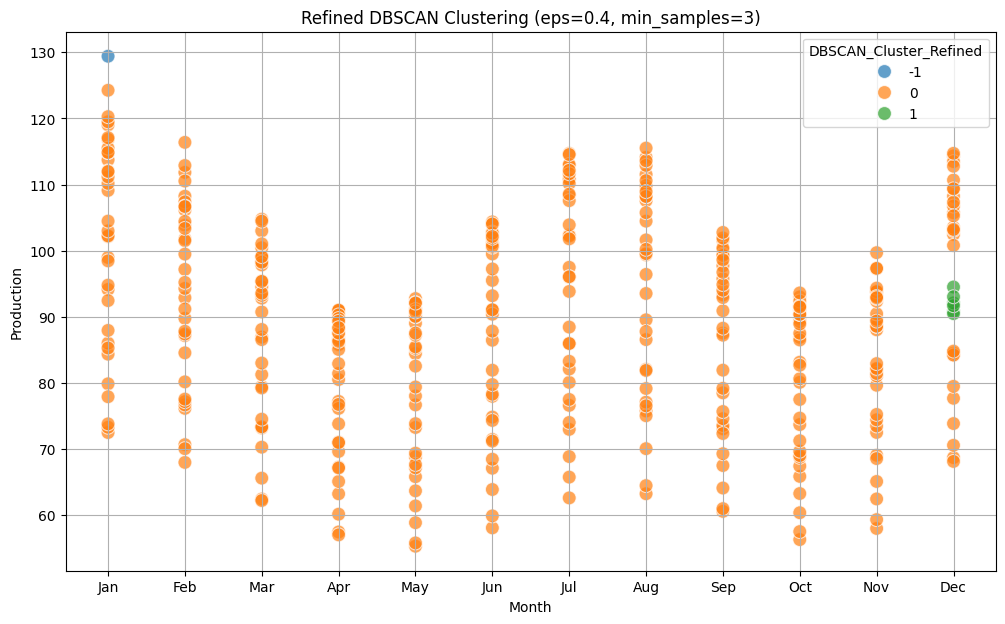

,Production,year,month,day,KMeans_Cluster,DBSCAN_Cluster,DBSCAN_Cluster_Refined
DATE,,,,,,,
1985-01-01,72.5052,1985,1,1,0,0,0
1985-02-01,70.6720,1985,2,1,0,0,0
1985-03-01,62.4502,1985,3,1,0,0,0
1985-04-01,57.4714,1985,4,1,0,0,0
1985-05-01,55.3151,1985,5,1,0,0,0


In [25]:
# Example visualization with refined DBSCAN parameters (adjust based on results_df)

# Let's pick an example (e.g., from the results_df where n_clusters > 1 and n_noise is manageable)
# For demonstration, let's assume we found a good combination like eps=0.2, min_samples=5

refined_eps = 0.4 # Adjusted based on observation of the results_df and k-distance graph
refined_min_samples = 3 # Adjusted this

dbscan_refined = DBSCAN(eps=refined_eps, min_samples=refined_min_samples)
df_clustering['DBSCAN_Cluster_Refined'] = dbscan_refined.fit_predict(df_scaled)

num_refined_dbscan_clusters = len(np.unique(df_clustering['DBSCAN_Cluster_Refined'][df_clustering['DBSCAN_Cluster_Refined'] != -1]))
print(f"Number of REFINED DBSCAN clusters found: {num_refined_dbscan_clusters}")

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_clustering, x='month', y='Production', hue='DBSCAN_Cluster_Refined', palette='tab10', s=100, alpha=0.7)
plt.title(f'Refined DBSCAN Clustering (eps={refined_eps}, min_samples={refined_min_samples})')
plt.xlabel('Month')
plt.ylabel('Production')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.show()

display(df_clustering.head())

### Identifying Unusual Electricity Patterns (DBSCAN Outliers)

In DBSCAN, data points that are not assigned to any cluster are labeled with `-1`. These points are considered 'noise' or 'outliers' and can represent unusual or anomalous electricity patterns. Let's extract and analyze these points.

In [26]:
# Filter for data points labeled as noise (-1) by the refined DBSCAN model
unusual_electricity_patterns = df_clustering[df_clustering['DBSCAN_Cluster_Refined'] == -1]

print(f"Number of unusual electricity patterns (outliers) found: {len(unusual_electricity_patterns)}")
display(unusual_electricity_patterns.head())

Number of unusual electricity patterns (outliers) found: 1


,Production,year,month,day,KMeans_Cluster,DBSCAN_Cluster,DBSCAN_Cluster_Refined
DATE,,,,,,,
2018-01-01,129.4048,2018,1,1,1,-1,-1


#### Visualizing Unusual Electricity Patterns

To better understand these unusual patterns, let's visualize them within the context of the overall electricity production data. We will highlight the outliers in a distinct color.

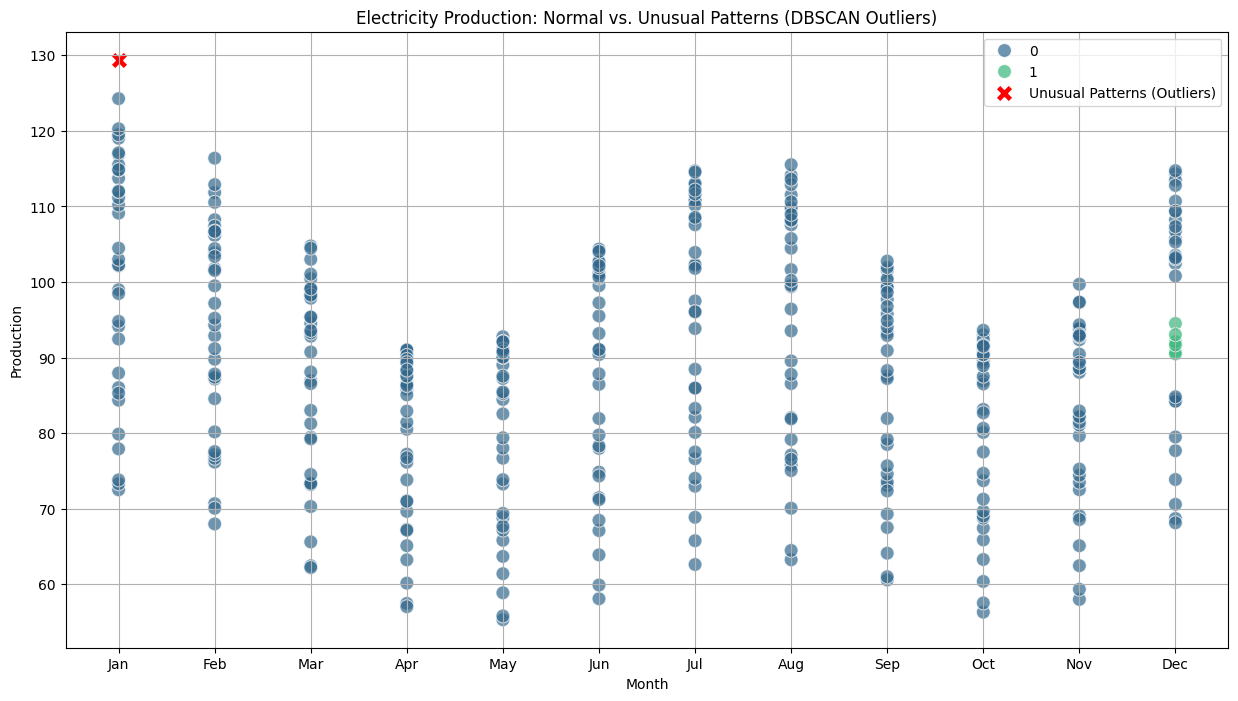

In [28]:
plt.figure(figsize=(15, 8))

# Plot all clustered data (non-outliers)
sns.scatterplot(data=df_clustering[df_clustering['DBSCAN_Cluster_Refined'] != -1],
                x='month', y='Production', hue='DBSCAN_Cluster_Refined',
                palette='viridis', s=100, alpha=0.7, legend='full') # Removed conflicting 'label' argument

# Plot the unusual electricity patterns (outliers)
sns.scatterplot(data=unusual_electricity_patterns,
                x='month', y='Production',
                color='red', s=150, marker='X', label='Unusual Patterns (Outliers)')

plt.title(f'Electricity Production: Normal vs. Unusual Patterns (DBSCAN Outliers)')
plt.xlabel('Month')
plt.ylabel('Production')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.legend()
plt.show()

### Download Clustered Data as a Pickle File

To save the `df_clustering` DataFrame (which now includes both K-Means and DBSCAN cluster assignments) for future use, we can serialize it into a `.pickle` file. This file can then be downloaded.

In [29]:
import pickle
from google.colab import files

# Define the filename
filename = 'clustered_electricity_data.pickle'

# Save the DataFrame to a pickle file
with open(filename, 'wb') as f:
    pickle.dump(df_clustering, f)

print(f"'{filename}' has been saved successfully.")

# Provide a download link
files.download(filename)

'clustered_electricity_data.pickle' has been saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>